In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

#----------------------------------------------------------------------
# CIFAR-10은 32 X 32 X 3의 해상도의 사물 데이터를 모아 놓은 데이터 세트
#----------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------
# [비행기(airplane), 자동차(automobile), 새(bird), 고양이(cat), 사슴(deer), 개(dog), 개구리(frog), 말(horse), 배(ship), 트럭(truck)]
#--------------------------------------------------------------------------------------------------------------------------------------------
# https://wikidocs.net/331475

# 1. 데이터 로드(Down)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CAT_LABEL = 3
DOG_LABEL = 5

print("original y_train shape:", y_train.shape)
print("original labels:", np.unique(y_train))


original y_train shape: (50000, 1)
original labels: [0 1 2 3 4 5 6 7 8 9]


In [7]:
# cat / dog 데이터 선택

y_train_flat = y_train.reshape(-1)
y_test_flat = y_test.reshape(-1)

train_mask = np.where((y_train_flat == CAT_LABEL) | (y_train_flat == DOG_LABEL))[0]
test_mask = np.where((y_test_flat == CAT_LABEL) | (y_test_flat == DOG_LABEL))[0]

print("train_mask size:", len(train_mask))
print("test_mask size:", len(test_mask))

# 평탄화 flat
x_train_cd = x_train[train_mask]
y_train_cd = y_train_flat[train_mask]

x_test_cd = x_test[test_mask]
y_test_cd = y_test_flat[test_mask]

# 행 열을 둘 다 찾을 경우 원하지 않는 세트들 (예: array([3, 5, 6])처럼 한 번에 묶여서 나오게 된다)
# 따라서 flat으로 평탄화(1차원으로 바꾸기)를 해주므로서 x_train에 train_mask 한 값을 주면 필요한 이미지만 골라올 수 있게 된다.



train_mask size: 10000
test_mask size: 2000


In [8]:
# 0 과 1로 변환

y_train_cd = np.where(y_train_cd == CAT_LABEL, 0, 1).astype("int32")
y_test_cd = np.where(y_test_cd == CAT_LABEL, 0, 1).astype("int32")

In [9]:
# 정규화

x_train_cd = x_train_cd.astype("float32") / 255.0
x_test_cd = x_test_cd.astype("float32") / 255.0

print("Train data:", x_train_cd.shape)
print("Train label:", y_train_cd.shape)
print("Test data:", x_test_cd.shape)
print("Test label:", y_test_cd.shape)
print("converted labels:", np.unique(y_train_cd))


Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)
converted labels: [0 1]


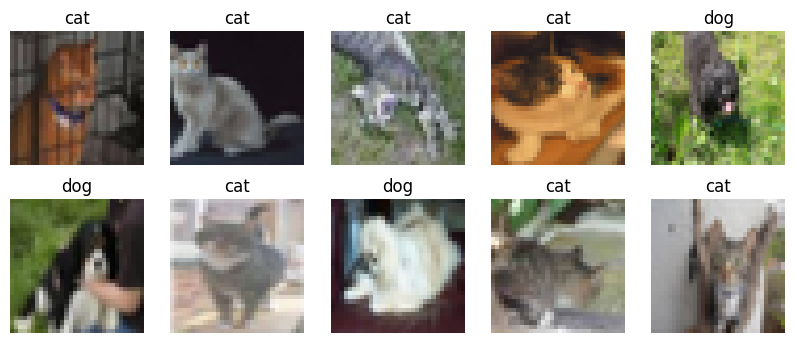

In [11]:
# 검증
import random

class_names = ["cat", "dog"]

plt.figure(figsize=(10, 4))

# x_train_cd에서 랜덤으로 10개의 인덱스 선택
random_indices = random.sample(range(len(x_train_cd)), 10)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[idx])

    label = int(y_train_cd[idx])
    plt.title(class_names[label])

    plt.axis("off")

plt.show()

In [24]:
# 번외편

# 모델 만들기
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 개(1) / 고양이(0) 이진 분류 출력층
])


# 채점 방식(손실 함수)과 나침반(옵티마이저) 설정
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 우리가 정제한 개/고양이 데이터(x_train_cd)로 학습 시작!
model.fit(x_train_cd, y_train_cd, epochs=3, batch_size=32)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.6168 - loss: 0.6487
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6887 - loss: 0.5899
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7119 - loss: 0.5538


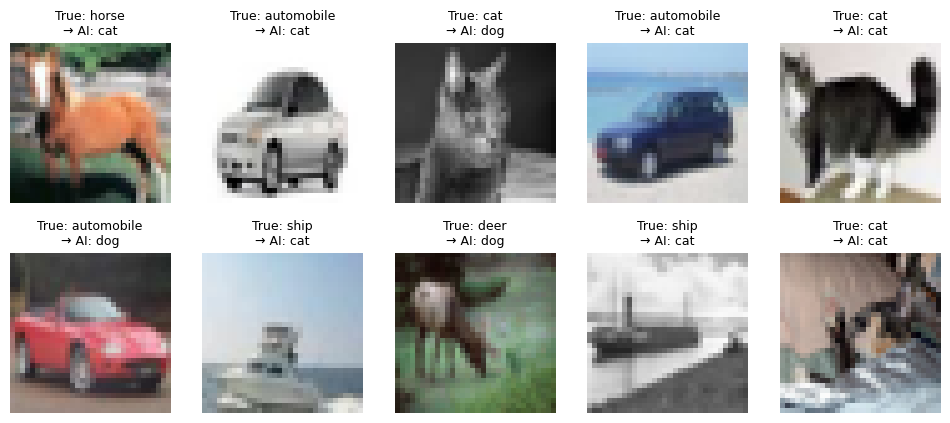

In [25]:
# 번외편

import random

# CIFAR-10 원본 라벨 이름 사전 (비행기, 트럭이 들어있음)
cifar10_original_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
real_class_names = ["cat", "dog"] # AI가 오해하게 될 세상

plt.figure(figsize=(12, 5))

# ⚠️ 비행기/트럭을 뽑기 위해 cd가 아닌 '원본 x_train'에서 랜덤 인덱스 10개 선택!
random_indices = random.sample(range(len(x_train)), 10)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)

    # 1. 원본 이미지 가져와서 화면에 그리기
    img_to_show = x_train[idx].astype("float32") / 255.0
    plt.imshow(img_to_show)

    # 2. [핵심] 반복문 안에서 각각의 이미지마다 모델에게 물어보기
    pred_prob = model.predict(img_to_show.reshape(1, 32, 32, 3), verbose=0)
    predicted_class = int(np.round(pred_prob[0][0])) # 0(고양이) 또는 1(개)

    # 3. 원본의 진짜 사물 이름 알아내기
    true_label_idx = y_train.reshape(-1)[idx]
    true_name = cifar10_original_names[true_label_idx]

    # 4. 타이틀에 "진짜 정답 -> AI의 오해" 근거를 명시하기
    plt.title(f"True: {true_name}\n→ AI: {real_class_names[predicted_class]}", fontsize=9)
    plt.axis("off")

plt.show()